# Model 6 — Feature Association Rule Mining (Apriori)

## Research Question
What combinations of car features tend to appear together — and do certain combinations reliably predict very expensive, very cheap, or heavily damaged cars?

## Introduction

This notebook uses the **Apriori algorithm** (`mlxtend`) to discover
association rules between binary car features.

**Parameters used in this notebook:**
- `min_support = 0.02` — lowered from the default 0.05 to allow rare
  target columns (`cok_pahali`, `cok_ucuz`) to appear in rules, as they
  represent exactly the top and bottom 5% of prices by construction.
- `metric = 'lift', min_threshold = 1.5` — lift was used as the primary
  filter instead of confidence, which is more appropriate for rare targets
  where absolute confidence is naturally low.
- `Kasa Tipi_SUV` was excluded from the transaction matrix (95% support)
  as it appeared in nearly every itemset without carrying discriminative
  information.

## Data Import

Run this cell as-is. It loads all required libraries and the unscaled dataset.

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install mlxtend -q
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Feature Engineering

Run this cell as-is. It creates seven custom binary columns that will be used as special items in the transaction matrix:

| Column | Meaning |
|---|---|
| `cok_pahali` | Price ≥ 95th percentile |
| `cok_ucuz` | Price ≤ 5th percentile |
| `yuksek_km` | Mileage > 150,000 km |
| `dusuk_km` | Mileage < 30,000 km |
| `yeni_araba` | Year ≥ 2022 |
| `eski_araba` | Year ≤ 2015 |
| `agir_hasar` | Damage score ≥ 75th percentile |

In [5]:
# Create custom binary columns for association mining
df['cok_pahali'] = (df['Fiyat'] >= df['Fiyat'].quantile(0.95)).astype(int)
df['cok_ucuz']   = (df['Fiyat'] <= df['Fiyat'].quantile(0.05)).astype(int)
df['yuksek_km']  = (df['Kilometre'] > 150000).astype(int)
df['dusuk_km']   = (df['Kilometre'] < 30000).astype(int)
df['yeni_araba'] = (df['Yıl'] >= 2022).astype(int)
df['eski_araba'] = (df['Yıl'] <= 2015).astype(int)
df['agir_hasar'] = (df['paint_damage_score'] >= df['paint_damage_score'].quantile(0.75)).astype(int)

print("Engineered columns created:")
for col in ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar']:
    print(f"  {col}: {df[col].sum()} cars ({df[col].mean()*100:.1f}%)")

Engineered columns created:
  cok_pahali: 130 cars (5.0%)
  cok_ucuz: 130 cars (5.0%)
  yuksek_km: 837 cars (32.3%)
  dusuk_km: 402 cars (15.5%)
  yeni_araba: 773 cars (29.9%)
  eski_araba: 823 cars (31.8%)
  agir_hasar: 828 cars (32.0%)


## Transaction Dataset Construction

Run this cell as-is. It combines the engineered binary columns with all existing one-hot encoded columns (body type, fuel type, drivetrain, seller type, brand flags) into a boolean transaction matrix suitable for Apriori.

In [6]:
# Combine engineered columns with existing binary one-hot columns
engineered_cols = ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km',
                   'yeni_araba', 'eski_araba', 'agir_hasar']

# Find all existing binary one-hot columns
onehot_patterns = ['Kasa Tipi_', 'Yakıt Tipi_', 'Çekiş_', 'Kimden_', 'is_Nissan']
onehot_cols = [c for c in df.columns for p in onehot_patterns if c.startswith(p)]

transaction_cols = engineered_cols + onehot_cols
transaction_cols = [c for c in transaction_cols if c in df.columns]

transactions = df[transaction_cols].fillna(0).astype(bool)
print(f"Transaction matrix: {transactions.shape[0]} rows × {transactions.shape[1]} items")
print(f"Total item columns: {transactions.columns.tolist()}")

Transaction matrix: 2589 rows × 23 items
Total item columns: ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar', 'is_Nissan', 'Kimden_Sahibinden', 'Kimden_Yetkili Bayiden', 'Yakıt Tipi_Dizel', 'Yakıt Tipi_Elektrik', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_LPG & Benzin', 'Kasa Tipi_Coupe', 'Kasa Tipi_Crossover', 'Kasa Tipi_Hard top', 'Kasa Tipi_Panelvan', 'Kasa Tipi_Pick-Up', 'Kasa Tipi_SUV', 'Çekiş_AWD (Elektronik)', 'Çekiş_Arkadan İtiş', 'Çekiş_Önden Çekiş']


## Frequent Itemset Mining

The **Apriori** algorithm to find frequent itemsets.

- Lower `min_support` → more itemsets found, but may include noisy/spurious ones
- Higher `min_support` → fewer, more reliable itemsets
- Adjust `max_len` to control the maximum number of items per itemset

In [7]:
# Lower min_support to 0.02 so that combinations involving rare targets
# (cok_pahali, cok_ucuz at ~5%) can survive the pruning step.
# cok_pahali ∩ yeni_araba could realistically be ~2-3% of all cars.

# Also exclude Kasa Tipi_SUV: present in 95% of cars, it adds noise
# to every itemset without carrying useful discriminative information.
non_informative = ['Kasa Tipi_SUV']
filtered_transactions = transactions.drop(columns=non_informative, errors='ignore')

frequent_itemsets = apriori(
    filtered_transactions,
    min_support=0.02,    # low enough to capture rare target combinations
    use_colnames=True,
    max_len=4
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(f"\nBreakdown by itemset size:")
print(frequent_itemsets['length'].value_counts().sort_index())

# Check if target columns now appear in the itemsets
target_cols = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
print(f"\nTarget columns appearing in itemsets:")
for t in target_cols:
    count = frequent_itemsets['itemsets'].apply(lambda x: t in x).sum()
    print(f"  {t}: {count} itemsets")

frequent_itemsets.sort_values('support', ascending=False).head(20)

Total frequent itemsets found: 209

Breakdown by itemset size:
length
1    16
2    56
3    81
4    56
Name: count, dtype: int64

Target columns appearing in itemsets:
  cok_pahali: 8 itemsets
  cok_ucuz: 28 itemsets
  agir_hasar: 57 itemsets


,support,itemsets,length
15,0.791039,(Çekiş_Önden Çekiş),1
7,0.517574,(is_Nissan),1
9,0.491696,(Yakıt Tipi_Dizel),1
62,0.443028,"(Çekiş_Önden Çekiş, is_Nissan)",2
8,0.368482,(Kimden_Sahibinden),1
69,0.354577,"(Çekiş_Önden Çekiş, Yakıt Tipi_Dizel)",2
2,0.323291,(yuksek_km),1
6,0.319815,(agir_hasar),1
5,0.317883,(eski_araba),1
58,0.305137,"(Yakıt Tipi_Dizel, is_Nissan)",2


## Association Rules Generation

Generate of association rules from the frequent itemsets.

- Higher `min_threshold` for confidence → fewer but more reliable rules
- Sort by `lift` to find rules where the co-occurrence is much higher than chance

In [8]:
# min_threshold lowered to 0.4 to allow more rules involving rare targets
# We sort by lift: values > 2.0 indicate a genuinely strong association

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.4
)

rules = rules.sort_values('lift', ascending=False)

rules['rule_str'] = rules.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

print(f"Total rules generated: {len(rules)}")
print(f"Rules with lift > 2.0 (strong): {len(rules[rules['lift'] > 2.0])}")
print(f"\nTop 10 rules by lift:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total rules generated: 618
Rules with lift > 2.0 (strong): 259

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
526,"(Çekiş_Önden Çekiş, Yakıt Tipi_Hibrit)","(yeni_araba, is_Nissan)",0.025879,0.971014,10.697687
529,(Yakıt Tipi_Hibrit),"(Çekiş_Önden Çekiş, yeni_araba, is_Nissan)",0.025879,0.788235,10.684509
190,(Yakıt Tipi_Hibrit),"(yeni_araba, is_Nissan)",0.030900,0.941176,10.368961
343,(cok_ucuz),"(eski_araba, Yakıt Tipi_Dizel, Kimden_Sahibinden)",0.020085,0.400000,5.850847
308,(cok_ucuz),"(eski_araba, yuksek_km, Yakıt Tipi_Dizel)",0.043646,0.869231,5.654368
60,(cok_pahali),"(yeni_araba, dusuk_km)",0.038625,0.769231,5.254719
63,(cok_pahali),"(yeni_araba, is_Nissan)",0.023175,0.461538,5.084779
58,"(cok_pahali, yeni_araba)",(dusuk_km),0.038625,0.775194,4.992479
0,(cok_pahali),(dusuk_km),0.038625,0.769231,4.954076
328,"(cok_ucuz, agir_hasar)","(eski_araba, Yakıt Tipi_Dizel)",0.022402,0.906250,4.939539


##Coloumns to display

For the next parts of the notebook the focus coloumns to use

In [9]:
# Columns to display in all evaluation tables
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']


## Why Lift Instead of Confidence?

`cok_pahali` and `cok_ucuz` represent by construction exactly the top
and bottom 5% of prices in the dataset. This creates a mathematical
constraint: any rule predicting these targets will have a naturally low
confidence, even when the association is genuinely strong.

For example, the rule `{yeni_araba, dusuk_km} → {cok_pahali}` has a
confidence of 0.26 — meaning 26% of new low-mileage cars are very
expensive. Filtered by confidence alone, this rule would be discarded
as too weak. Yet its lift is 5.25, meaning this combination is 5x more
likely to predict an expensive car than random chance. That is a strong
and meaningful association.

Lift normalizes by the rarity of the target:

    lift = confidence / P(target)
         = 0.26 / 0.05
         = 5.2

This is why lift was used as the primary filtering metric for
target-specific rules (`rules_target`), while confidence was kept as
the main metric only for general structural rules (`rules`).
A lift threshold of 1.5 was applied — meaning only

In [10]:
# Use lift as the primary filter metric instead of confidence.
# This is more appropriate for rare targets (cok_pahali, cok_ucuz at ~5%):
# a rule can have low confidence but very high lift — meaning the association
# is much stronger than chance even if the absolute probability is small.

rules_target = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.5   # only keep rules that are 1.5x better than random chance
)

rules_target = rules_target.sort_values('lift', ascending=False)

rules_target['rule_str'] = rules_target.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

print(f"Total rules: {len(rules_target)}")

for target in ['cok_pahali', 'cok_ucuz', 'agir_hasar']:
    count = rules_target['consequents'].apply(lambda x: target in x).sum()
    print(f"  Rules predicting {target}: {count}")

Total rules: 818
  Rules predicting cok_pahali: 9
  Rules predicting cok_ucuz: 92
  Rules predicting agir_hasar: 142


## Evaluation

### Top Rules Predicting Very Expensive Cars (`cok_pahali`)

Filters rules whose consequent is `cok_pahali` and ranks them by confidence.


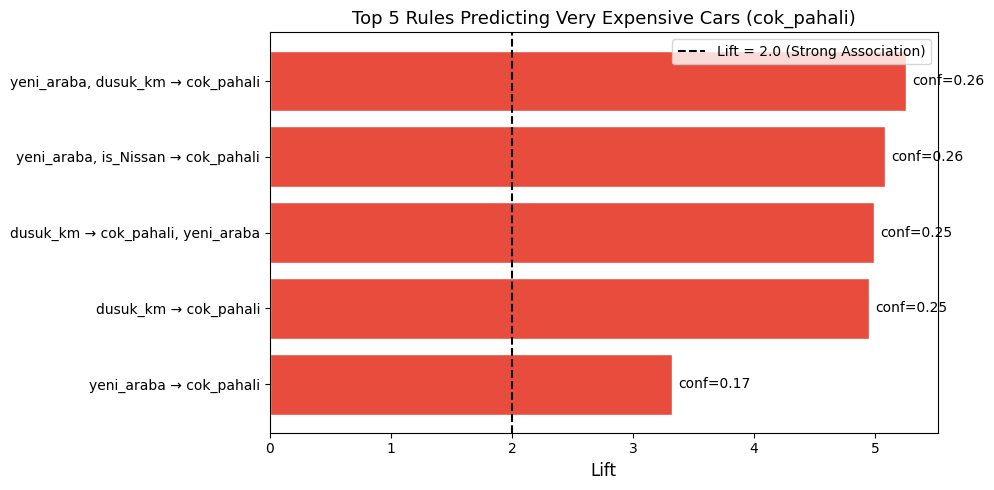

In [11]:

# Filter and sort rules predicting very expensive cars
pahali_rules = rules_target[rules_target['consequents'].apply(lambda x: 'cok_pahali' in x)]
pahali_rules_sorted = pahali_rules.sort_values('confidence', ascending=False).head(5)

if len(pahali_rules_sorted) > 0:
    # Build readable rule labels
    pahali_rules_sorted = pahali_rules_sorted.copy()
    pahali_rules_sorted['rule_label'] = pahali_rules_sorted.apply(
        lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
        axis=1
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(
        pahali_rules_sorted['rule_label'],
        pahali_rules_sorted['lift'],
        color='#e74c3c',
        edgecolor='white'
    )

    # Display confidence value on each bar
    for bar, (_, row) in zip(bars, pahali_rules_sorted.iterrows()):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"conf={row['confidence']:.2f}",
            va='center', fontsize=10
        )

    ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5,
               label='Lift = 2.0 (Strong Association)')
    ax.set_xlabel('Lift', fontsize=12)
    ax.set_title('Top 5 Rules Predicting Very Expensive Cars (cok_pahali)', fontsize=13)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No rules found. Try lowering min_support or min_threshold.")

### Top Rules Predicting Very Cheap Cars (`cok_ucuz`)

Filters rules whose consequent is `cok_ucuz` and ranks them by confidence.


=== Top 10 Rules Predicting VERY CHEAP Cars ===

                                    antecedents                consequents  support  confidence     lift
eski_araba, Yakıt Tipi_Dizel, Kimden_Sahibinden                   cok_ucuz 0.020085    0.293785 5.850847
        eski_araba, yuksek_km, Yakıt Tipi_Dizel                   cok_ucuz 0.043646    0.283920 5.654368
                   eski_araba, Yakıt Tipi_Dizel                   cok_ucuz 0.044419    0.242105 4.821619
                   eski_araba, Yakıt Tipi_Dizel        yuksek_km, cok_ucuz 0.043646    0.237895 4.849681
       eski_araba, Yakıt Tipi_Dizel, agir_hasar                   cok_ucuz 0.022402    0.232000 4.620369
       eski_araba, yuksek_km, Kimden_Sahibinden                   cok_ucuz 0.023175    0.224719 4.475367
                          eski_araba, yuksek_km                   cok_ucuz 0.049054    0.223592 4.452912
               eski_araba, yuksek_km, is_Nissan                   cok_ucuz 0.031672    0.206030 4.103170
      

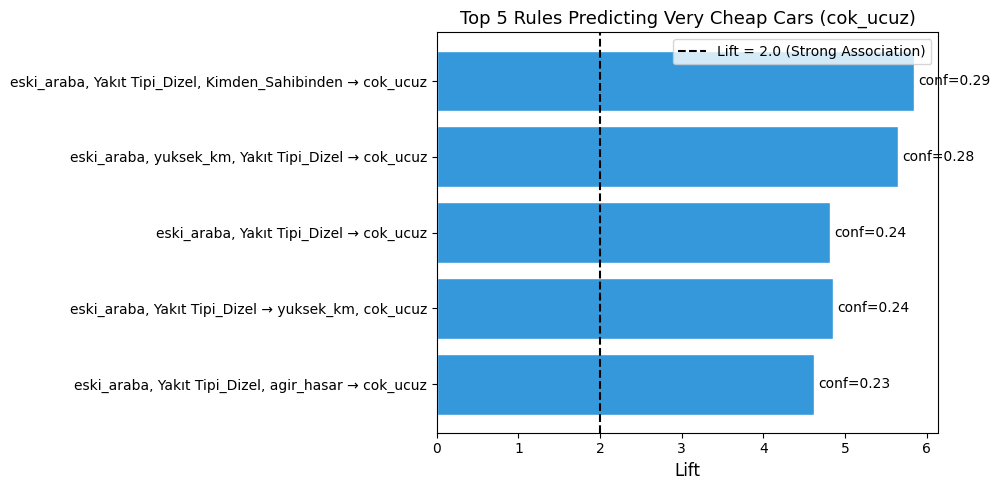

In [13]:

ucuz_rules = rules_target[rules_target['consequents'].apply(lambda x: 'cok_ucuz' in x)]
ucuz_rules_sorted = ucuz_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting VERY CHEAP Cars ===\n")
if len(ucuz_rules_sorted) > 0:
    styled = ucuz_rules_sorted[display_cols].reset_index(drop=True).copy()
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))

#Horizontal chart

# Filter and sort rules predicting very cheap cars
ucuz_rules = rules_target[rules_target['consequents'].apply(lambda x: 'cok_ucuz' in x)]
ucuz_rules_sorted = ucuz_rules.sort_values('confidence', ascending=False).head(5)

if len(ucuz_rules_sorted) > 0:
    ucuz_rules_sorted = ucuz_rules_sorted.copy()
    ucuz_rules_sorted['rule_label'] = ucuz_rules_sorted.apply(
        lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
        axis=1
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(
        ucuz_rules_sorted['rule_label'],
        ucuz_rules_sorted['lift'],
        color='#3498db',
        edgecolor='white'
    )

    # Display confidence value on each bar
    for bar, (_, row) in zip(bars, ucuz_rules_sorted.iterrows()):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"conf={row['confidence']:.2f}",
            va='center', fontsize=10
        )

    ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5,
               label='Lift = 2.0 (Strong Association)')
    ax.set_xlabel('Lift', fontsize=12)
    ax.set_title('Top 5 Rules Predicting Very Cheap Cars (cok_ucuz)', fontsize=13)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No rules found. Try lowering min_support or min_threshold.")

### Top Rules Predicting Heavily Damaged Cars (`agir_hasar`)

Filters rules whose consequent is `agir_hasar` and ranks them by confidence.


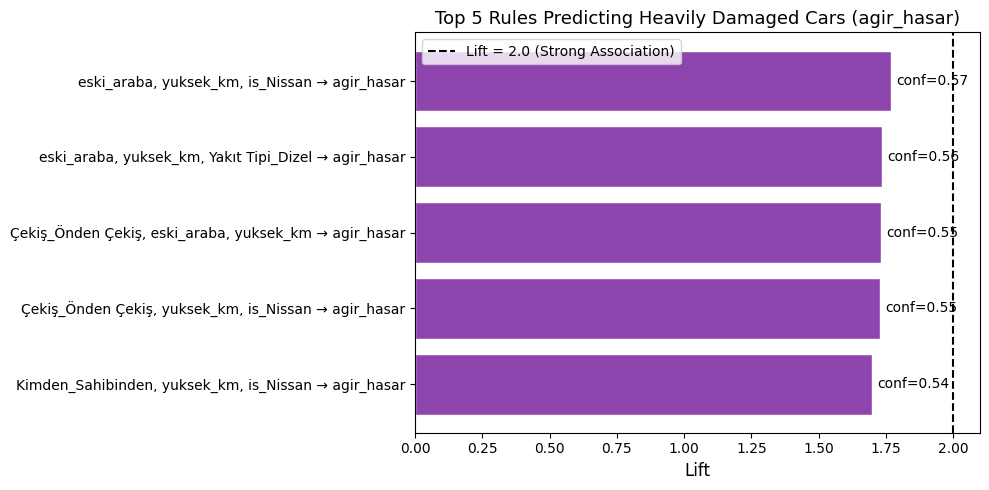

In [14]:

# Filter and sort rules predicting heavily damaged cars
hasar_rules = rules_target[rules_target['consequents'].apply(lambda x: 'agir_hasar' in x)]
hasar_rules_sorted = hasar_rules.sort_values('confidence', ascending=False).head(5)

if len(hasar_rules_sorted) > 0:
    hasar_rules_sorted = hasar_rules_sorted.copy()
    hasar_rules_sorted['rule_label'] = hasar_rules_sorted.apply(
        lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
        axis=1
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(
        hasar_rules_sorted['rule_label'],
        hasar_rules_sorted['lift'],
        color='#8e44ad',
        edgecolor='white'
    )

    # Display confidence value on each bar
    for bar, (_, row) in zip(bars, hasar_rules_sorted.iterrows()):
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"conf={row['confidence']:.2f}",
            va='center', fontsize=10
        )

    ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5,
               label='Lift = 2.0 (Strong Association)')
    ax.set_xlabel('Lift', fontsize=12)
    ax.set_title('Top 5 Rules Predicting Heavily Damaged Cars (agir_hasar)', fontsize=13)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No rules found. Try lowering min_support or min_threshold.")


### Top 10 Rules by Lift (Strongest Natural Associations)

Lift > 1 means the items co-occur more than expected by chance. Lift > 2 is considered a strong association.

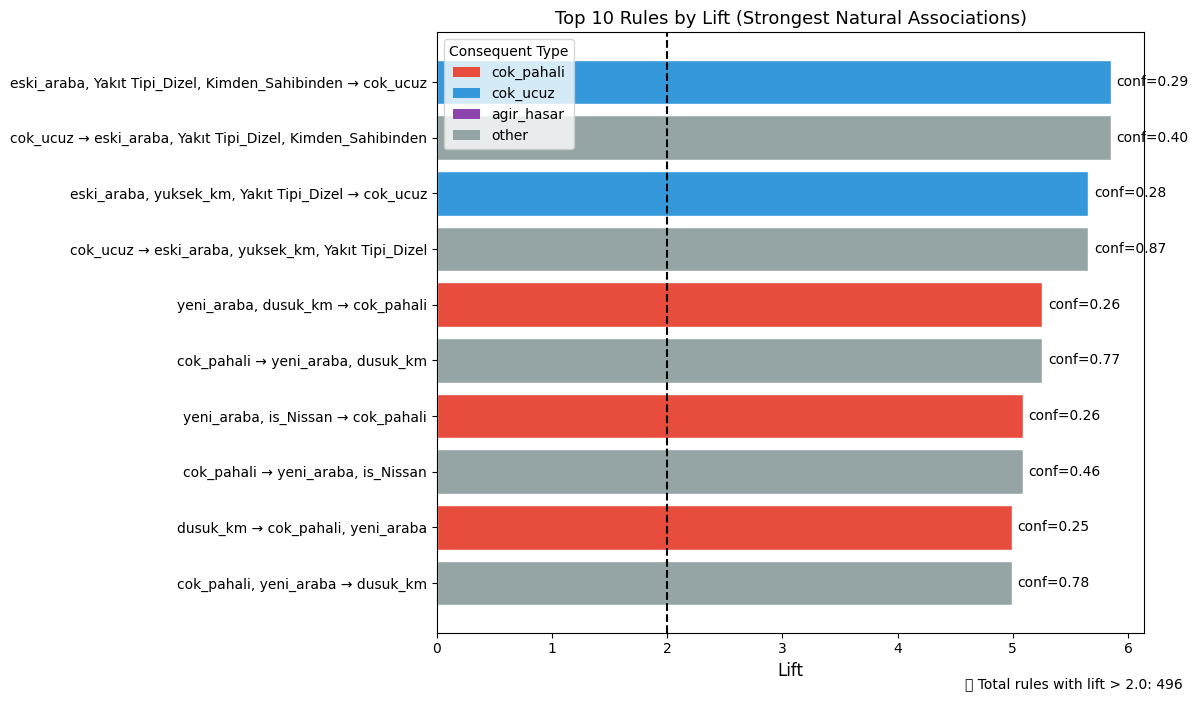

In [15]:
# Exclude all rules involving Yakıt Tipi_Hibrit — these are brand tautologies
# (almost all hybrids in the dataset are Nissan) and carry no useful
# predictive information about price or damage.
def contains_hibrit(row):
    all_items = set(row['antecedents']) | set(row['consequents'])
    return 'Yakıt Tipi_Hibrit' in all_items

top10_lift = rules_target[~rules_target.apply(contains_hibrit, axis=1)] \
                .sort_values('lift', ascending=False) \
                .head(10) \
                .reset_index(drop=True)

# Build readable rule labels
top10_lift['rule_label'] = top10_lift.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

# Assign color based on consequent type
def get_bar_color(row):
    consequents = set(row['consequents'])
    if 'cok_pahali' in consequents:
        return '#e74c3c'
    elif 'cok_ucuz' in consequents:
        return '#3498db'
    elif 'agir_hasar' in consequents:
        return '#8e44ad'
    else:
        return '#95a5a6'

top10_lift['color'] = top10_lift.apply(get_bar_color, axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top10_lift['rule_label'],
    top10_lift['lift'],
    color=top10_lift['color'],
    edgecolor='white'
)

# Display confidence value on each bar
for bar, (_, row) in zip(bars, top10_lift.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"conf={row['confidence']:.2f}",
        va='center', fontsize=10
    )

ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5,
           label='Lift = 2.0 (Strong Association)')
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 10 Rules by Lift (Strongest Natural Associations)', fontsize=13)
ax.invert_yaxis()

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='cok_pahali'),
    Patch(facecolor='#3498db', label='cok_ucuz'),
    Patch(facecolor='#8e44ad', label='agir_hasar'),
    Patch(facecolor='#95a5a6', label='other'),
]
ax.legend(handles=legend_elements, title='Consequent Type', fontsize=10)

strong_all = rules_target[rules_target['lift'] > 2.0]
plt.figtext(0.99, 0.01, f'⭐ Total rules with lift > 2.0: {len(strong_all)}',
            ha='right', fontsize=10)

plt.tight_layout()
plt.show()

### Support vs Confidence Scatter Plot

Each point is one association rule. Point size encodes lift. Color indicates the type of consequent:
- 🔴 Red = `cok_pahali` (very expensive)
- 🔵 Blue = `cok_ucuz` (very cheap)
- 🟣 Purple = `agir_hasar` (heavy damage)
- ⚫ Grey = other consequents


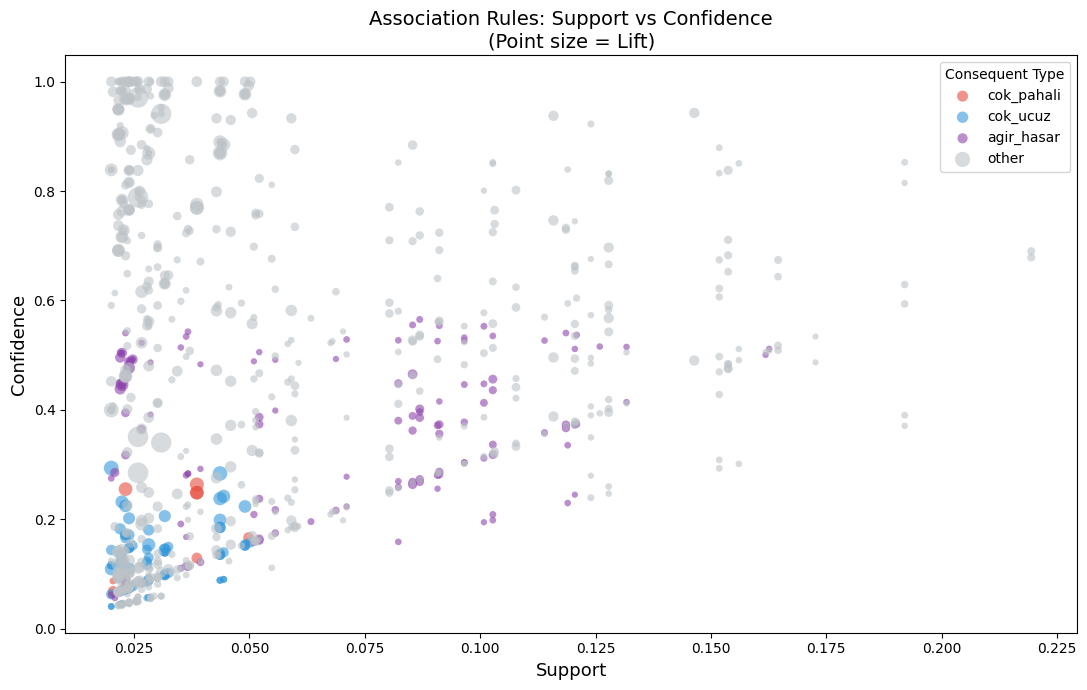

In [16]:

target_consequents = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
color_map = {'cok_pahali': '#e74c3c', 'cok_ucuz': '#3498db', 'agir_hasar': '#8e44ad', 'other': '#bdc3c7'}

def get_color(row):
    for t in target_consequents:
        if t in row['consequents']:
            return color_map[t]
    return color_map['other']

plot_rules = rules_target.copy()
plot_rules['color'] = plot_rules.apply(get_color, axis=1)
plot_rules['lift_scaled'] = (plot_rules['lift'] - plot_rules['lift'].min()) / (plot_rules['lift'].max() - plot_rules['lift'].min() + 1e-9) * 200 + 20

fig, ax = plt.subplots(figsize=(11, 7))
for label, color in color_map.items():
    mask = plot_rules['color'] == color
    if mask.sum() > 0:
        ax.scatter(plot_rules.loc[mask, 'support'],
                   plot_rules.loc[mask, 'confidence'],
                   s=plot_rules.loc[mask, 'lift_scaled'],
                   c=color, alpha=0.6, label=label, edgecolors='none')

ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Association Rules: Support vs Confidence\n(Point size = Lift)', fontsize=14)
ax.legend(title='Consequent Type')
plt.tight_layout()
plt.show()

### Top 10 Rules by Lift — Bar Chart

Horizontal bar chart of the 10 rules with the highest lift. Rules with lift > 2.0 are highlighted in red.

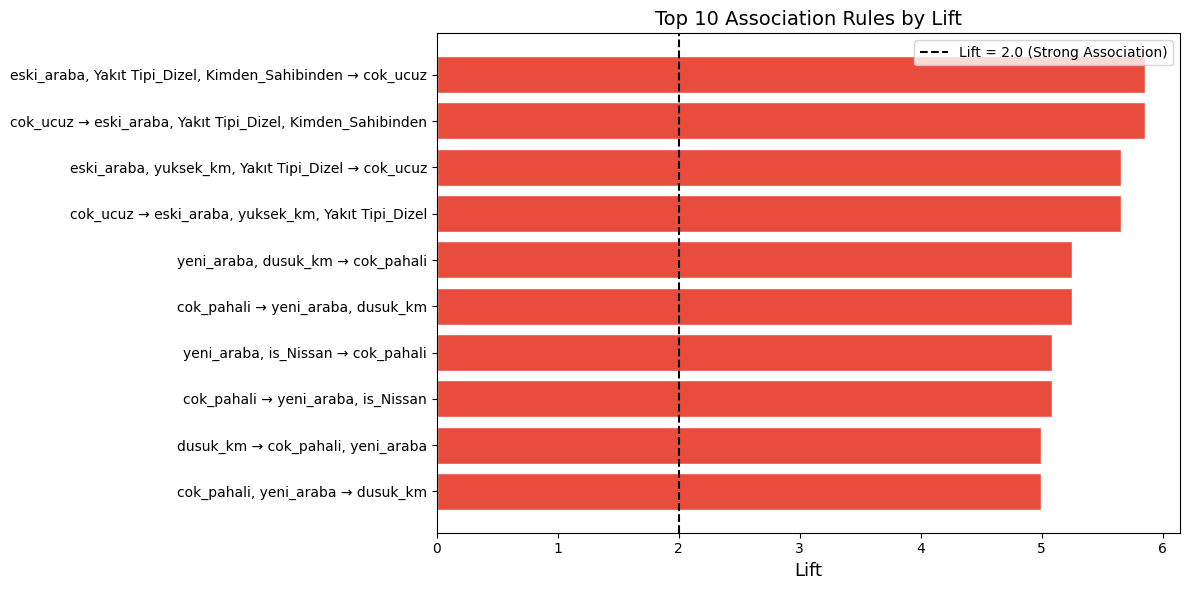

In [17]:
# Exclude Yakıt Tipi_Hibrit tautology rules before plotting
def contains_hibrit(row):
    all_items = set(row['antecedents']) | set(row['consequents'])
    return 'Yakıt Tipi_Hibrit' in all_items

top10_lift = rules_target[~rules_target.apply(contains_hibrit, axis=1)] \
                .nlargest(10, 'lift') \
                .reset_index(drop=True)

top10_lift['rule_label'] = top10_lift.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}", axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r['lift'] > 2 else '#3498db' for _, r in top10_lift.iterrows()]
ax.barh(top10_lift['rule_label'], top10_lift['lift'], color=colors, edgecolor='white')
ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5, label='Lift = 2.0 (Strong Association)')
ax.set_xlabel('Lift', fontsize=13)
ax.set_title('Top 10 Association Rules by Lift', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Supplementary Analysis

### Graph 1: Correlation Between Engineered Target Columns

The heatmap below shows how the seven engineered binary columns relate
to each other. Strong positive correlations (green) confirm associations
found by Apriori, while negative correlations (red) highlight natural
opposites such as `yeni_araba` and `eski_araba`.

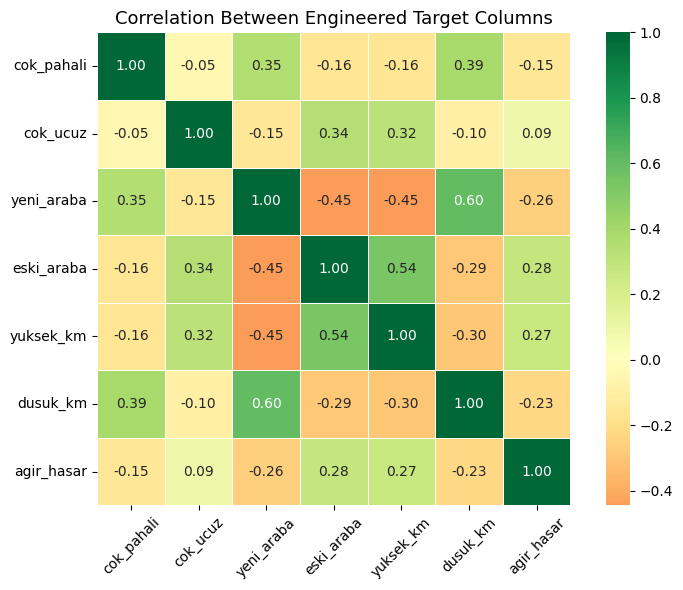

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

target_cols = ['cok_pahali', 'cok_ucuz', 'yeni_araba', 'eski_araba',
               'yuksek_km', 'dusuk_km', 'agir_hasar']
corr_matrix = df[target_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Between Engineered Target Columns', fontsize=13)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Graph 2: Apriori Pruning Effect — Frequent Itemsets by Size

One of Apriori's core strengths is its ability to reduce the search space
by pruning infrequent itemsets at each iteration. The chart below shows
how the number of frequent itemsets evolves as itemset size increases,
illustrating the antimonotonicity principle in action.

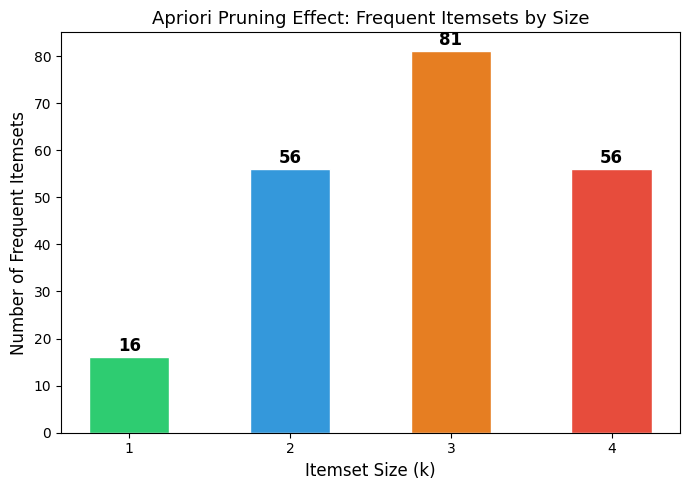

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

itemset_counts = frequent_itemsets['length'].value_counts().sort_index()
bars = ax.bar(
    itemset_counts.index,
    itemset_counts.values,
    color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'],
    edgecolor='white',
    width=0.5
)

# Add count labels on top of each bar
for bar, count in zip(bars, itemset_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_xlabel('Itemset Size (k)', fontsize=12)
ax.set_ylabel('Number of Frequent Itemsets', fontsize=12)
ax.set_title('Apriori Pruning Effect: Frequent Itemsets by Size', fontsize=13)
ax.set_xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

### Graph 3: Average Lift by Target Outcome

The bar chart below summarizes the average lift of all rules pointing
toward each of the three target outcomes. A higher average lift indicates
that the target is more predictable from observable car features.
This chart visually confirms the main conclusion of this notebook:
price extremes are strongly predictable, while heavy damage is not.

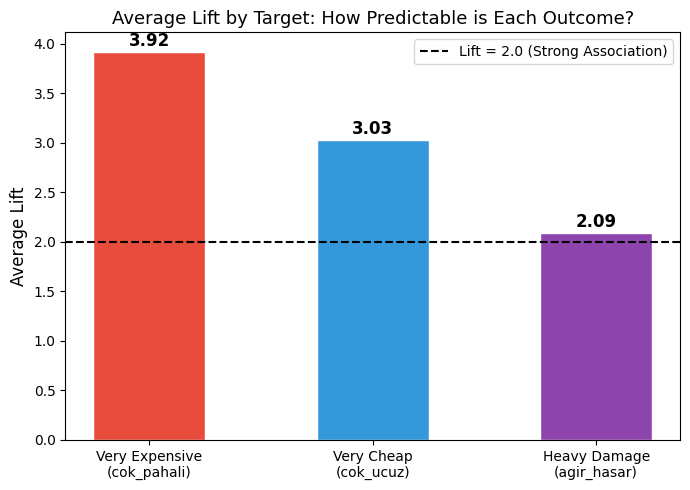

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

target_labels = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
avg_lifts = []
for target in target_labels:
    mask = rules_target['consequents'].apply(lambda x: target in x)
    avg_lifts.append(rules_target[mask]['lift'].mean())

colors_lift = ['#e74c3c', '#3498db', '#8e44ad']
bars = ax.bar(target_labels, avg_lifts, color=colors_lift,
              edgecolor='white', width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_lifts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.axhline(2.0, color='black', linestyle='--', linewidth=1.5,
           label='Lift = 2.0 (Strong Association)')
ax.set_ylabel('Average Lift', fontsize=12)
ax.set_title('Average Lift by Target: How Predictable is Each Outcome?', fontsize=13)
ax.set_xticklabels(['Very Expensive\n(cok_pahali)',
                    'Very Cheap\n(cok_ucuz)',
                    'Heavy Damage\n(agir_hasar)'], fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Conclusion

**Price is highly predictable.**
The model found strong rules for both price extremes (lift > 5.0).
Very expensive cars are consistently associated with low mileage and recent
year (`yeni_araba + dusuk_km → cok_pahali`, lift=5.25), while very cheap cars
are strongly linked to old age, high mileage, and diesel fuel
(`eski_araba + yuksek_km + Yakıt Tipi_Dizel → cok_ucuz`, lift=5.65).
These two profiles are near-perfect opposites, reflecting a well-structured
market where freshness drives value and wear drives depreciation.

**Damage is largely unpredictable.**
No rule predicting `agir_hasar` exceeded a lift of 1.77, well below the
threshold of 2.0 considered a strong association. High mileage (`yuksek_km`)
was the only consistent predictor, suggesting that paint and body damage
depends more on individual vehicle history than on observable structural
features.

**Modeling note.**
Two parameter adjustments were necessary to surface meaningful rules.
First, `min_support` was lowered from 0.05 to 0.02, as target columns
(`cok_pahali`, `cok_ucuz`) represent exactly the top and bottom 5% of prices
by construction — combinations involving them fall below any 5% threshold.
Second, rules were filtered by lift rather than confidence, which is more
appropriate for rare targets where absolute confidence is naturally low.

### Limitations

The dataset is heavily dominated by a single body type (SUV, 95% of cars)
and a single brand (Nissan, ~52%), which limits the generalizability of
brand-specific rules. Future work could apply Apriori to a more balanced
dataset or combine these association rules with a supervised model to
move from description to prediction.